# # Análisis de rendimiento en League of Legends
# ## Jugador: KBTZASK8#9829
#
# **Objetivo general:** identificar patrones de rendimiento que puedan ayudar al jugador a tomar mejores decisiones y aumentar su consistencia al competir.
#
# El análisis se divide en:
# 1. Carga de datos
# 2. Exploración inicial
# 3. Limpieza
# 4. Indicadores generales
# 5. Comparación de victorias y derrotas
# 6. Análisis por campeón
# 7. Forma reciente
# 8. Relación entre variables y victoria
# 9. CS/min frente a oro/min
# 10. Diagnóstico y plan de mejora



In [ ]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.2f}")

In [ ]:
import json
import math
import os
import sys
import time
from datetime import datetime
from pathlib import Path
from urllib.parse import quote
from zoneinfo import ZoneInfo

import pandas as pd
import requests


# CONFIGURACIÓN


API_KEY = "RGAPI-8696a14c-1892-452f-bbbf-08273ce1aea8".strip()

if not API_KEY:
    raise RuntimeError(
        "Falta la API key. Defínela antes de correr el script:\n"
        "  Windows (PowerShell): $env:RIOT_API_KEY=\"RGAPI-...\"\n"
        "  Linux/macOS:          export RIOT_API_KEY=\"RGAPI-...\""
    )

GAME_NAME = "KBTZASK8"
TAG_LINE = "9829"

PLATFORM_REGION = "la1"          # LAN
REGIONAL_ROUTING = "americas"    # ACCOUNT-V1 y MATCH-V5
BASE_URL = f"https://{REGIONAL_ROUTING}.api.riotgames.com"

ZONA_HORARIA = ZoneInfo("America/Bogota")
YEAR = datetime.now(ZONA_HORARIA).year

_inicio = datetime(YEAR, 1, 1, tzinfo=ZONA_HORARIA)
_fin = min(datetime(YEAR + 1, 1, 1, tzinfo=ZONA_HORARIA), datetime.now(ZONA_HORARIA))
START_TIME = int(_inicio.timestamp())
END_TIME = int(_fin.timestamp())

# 420 -> Solo/Duo | 440 -> Flex | None -> ambas
RANKED_QUEUE = 420

# Máximo número de partidas a descargar
MAX_PARTIDAS = 100

# Dev key: 100 req / 2 min -> >= 1.2 s entre requests.
REQUEST_DELAY = 1.2

# Descargar el timeline (datos minuto a minuto). Duplica los requests.
DESCARGAR_TIMELINE = True

RANKED_QUEUES = {420: "Ranked Solo/Duo", 440: "Ranked Flex"}

SUMMONER_SPELLS = {
    1: "Purificar", 3: "Extenuación", 4: "Destello", 6: "Fantasmal",
    7: "Curar", 11: "Aplastar", 12: "Teleportar", 13: "Claridad",
    14: "Prender", 21: "Barrera", 32: "Marca",
}

# Consumibles cuyo uso aparece como ITEM_DESTROYED en el timeline.
# (La poción recargable 2031 NO se destruye al usarla, así que no se puede rastrear.)
CONSUMIBLES_CURACION = {
    2003: "Poción de vida",
    2010: "Galleta de voluntad perpetua",
}

# Fuentes aproximadas de cada equipo en la Grieta del Invocador (coordenadas del mapa)
FUENTES = {100: (400, 400), 200: (14400, 14400)}   # 100 = azul, 200 = rojo
RADIO_BASE = 2500

RAW_DIR = Path("data/raw")
TIMELINE_DIR = RAW_DIR / "timelines"
PROCESSED_DIR = Path("data/processed")
for d in (RAW_DIR, TIMELINE_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

session = requests.Session()
session.headers.update({"X-Riot-Token": API_KEY})



# REQUESTS


class RiotError(Exception):
    pass


class NotFound(RiotError):
    pass


def riot_get(url, params=None, max_reintentos=5):
    for intento in range(1, max_reintentos + 1):
        try:
            r = session.get(url, params=params, timeout=(5, 30))
        except (requests.Timeout, requests.ConnectionError) as e:
            espera = 2 ** intento
            print(f"  Error de red ({e.__class__.__name__}). Reintentando en {espera}s...")
            time.sleep(espera)
            continue

        if r.status_code == 200:
            return r.json()

        if r.status_code == 429:
            espera = int(r.headers.get("Retry-After", 5)) + 1
            print(f"  429 Rate limit. Esperando {espera}s (intento {intento}/{max_reintentos})...")
            time.sleep(espera)
            continue

        if r.status_code >= 500:
            espera = 2 ** intento
            print(f"  {r.status_code} del servidor. Reintentando en {espera}s...")
            time.sleep(espera)
            continue

        if r.status_code == 404:
            raise NotFound(f"404 Not Found: {url}")

        if r.status_code in (401, 403):
            raise RiotError(
                f"{r.status_code}: API key inválida, expirada o sin permisos.\n"
                "Las dev keys expiran cada 24 h; regenérala en developer.riotgames.com."
            )

        if r.status_code == 400:
            raise RiotError(f"400 Bad Request\nURL: {url}\nRespuesta: {r.text}")

        raise RiotError(f"HTTP {r.status_code}\nRespuesta: {r.text}")

    raise RiotError(f"Se agotaron los {max_reintentos} reintentos para:\n{url}")


def cargar_nombres_items():
    """Nombres de ítems en español desde Data Dragon (no usa la API key)."""
    cache = RAW_DIR / "items_es.json"
    if cache.exists():
        return {int(k): v for k, v in json.loads(cache.read_text(encoding="utf-8")).items()}
    try:
        version = requests.get(
            "https://ddragon.leagueoflegends.com/api/versions.json", timeout=15
        ).json()[0]
        data = requests.get(
            f"https://ddragon.leagueoflegends.com/cdn/{version}/data/es_MX/item.json",
            timeout=15,
        ).json()["data"]
        nombres = {int(k): v["name"] for k, v in data.items()}
        cache.write_text(json.dumps(nombres, ensure_ascii=False), encoding="utf-8")
        return nombres
    except Exception as e:
        print(f"  (No se pudieron cargar nombres de ítems: {e})")
        return {}



# 1. CUENTA


def get_account():
    print("\n[1/5] Buscando cuenta Riot...")
    url = (
        f"{BASE_URL}/riot/account/v1/accounts/by-riot-id/"
        f"{quote(GAME_NAME, safe='')}/{quote(TAG_LINE, safe='')}"
    )
    account = riot_get(url)
    print(f"Riot ID : {account['gameName']}#{account['tagLine']}")
    print(f"PUUID   : {account['puuid']}")
    return account



# 2. IDs DE PARTIDAS RANKED DEL AÑO


def get_match_ids(puuid):
    cola = RANKED_QUEUES.get(RANKED_QUEUE, "Ranked (Solo/Duo + Flex)")
    print(f"\n[2/5] Obteniendo historial de {cola} del {YEAR}...")
    print(f"  Desde: {_inicio:%Y-%m-%d}  Hasta: {_fin:%Y-%m-%d %H:%M} (hora Colombia)")
    print(f"  Máximo: {MAX_PARTIDAS} partidas")

    url = f"{BASE_URL}/lol/match/v5/matches/by-puuid/{puuid}/ids"
    match_ids, start, page_size = [], 0, 100

    while len(match_ids) < MAX_PARTIDAS:
        # Ajustar page_size para no exceder MAX_PARTIDAS
        count = min(page_size, MAX_PARTIDAS - len(match_ids))

        params = {"startTime": START_TIME, "endTime": END_TIME,
                  "start": start, "count": count}
        if RANKED_QUEUE is not None:
            params["queue"] = RANKED_QUEUE
        else:
            params["type"] = "ranked"

        pagina = riot_get(url, params=params)
        if not pagina:
            break

        match_ids.extend(pagina)
        start += len(pagina)
        print(f"  {len(match_ids)} IDs obtenidos...")

        if len(pagina) < count or len(match_ids) >= MAX_PARTIDAS:
            break
        time.sleep(REQUEST_DELAY)

    match_ids = list(dict.fromkeys(match_ids))[:MAX_PARTIDAS]
    print(f"Partidas ranked encontradas: {len(match_ids)} (máximo: {MAX_PARTIDAS})")
    return match_ids



# 3. DESCARGA (partida + timeline, con caché)


def _descargar_con_cache(cache_file, url):
    """Devuelve (datos, hizo_request). datos es None si la API responde 404."""
    if cache_file.exists():
        return json.loads(cache_file.read_text(encoding="utf-8")), False
    try:
        data = riot_get(url)
    except NotFound:
        return None, True
    cache_file.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
    return data, True


def get_matches(match_ids):
    print("\n[3/5] Descargando partidas" + (" y timelines..." if DESCARGAR_TIMELINE else "..."))

    pendientes = sum(1 for m in match_ids if not (RAW_DIR / f"{m}.json").exists())
    if DESCARGAR_TIMELINE:
        pendientes += sum(1 for m in match_ids if not (TIMELINE_DIR / f"{m}.json").exists())
    print(f"  {pendientes} requests pendientes (~{pendientes * REQUEST_DELAY / 60:.0f} min)")

    resultados = []  # lista de (match, timeline)

    for i, match_id in enumerate(match_ids, start=1):
        match, req1 = _descargar_con_cache(
            RAW_DIR / f"{match_id}.json",
            f"{BASE_URL}/lol/match/v5/matches/{match_id}",
        )
        if req1:
            print(f"  [{i}/{len(match_ids)}] {match_id} partida")
            time.sleep(REQUEST_DELAY)
        if match is None:
            print("    -> partida no encontrada, se omite")
            continue

        timeline = None
        if DESCARGAR_TIMELINE:
            timeline, req2 = _descargar_con_cache(
                TIMELINE_DIR / f"{match_id}.json",
                f"{BASE_URL}/lol/match/v5/matches/{match_id}/timeline",
            )
            if req2:
                print(f"  [{i}/{len(match_ids)}] {match_id} timeline")
                time.sleep(REQUEST_DELAY)
            if timeline is None:
                print("    -> timeline no disponible")

        resultados.append((match, timeline))

    return resultados



# UTILIDADES DE PROCESAMIENTO


def partida_valida(match):
    info = match.get("info", {})
    gc = info.get("gameCreation")
    return (
        info.get("queueId") in RANKED_QUEUES
        and gc is not None
        and START_TIME * 1000 <= gc < END_TIME * 1000
    )


def buscar_jugador(match, puuid):
    return next(
        (p for p in match["info"].get("participants", []) if p.get("puuid") == puuid),
        None,
    )


def participant_id_timeline(timeline, puuid, player):
    """ID (1-10) del jugador dentro del timeline."""
    for p in timeline.get("info", {}).get("participants", []):
        if p.get("puuid") == puuid:
            return p.get("participantId")
    return player.get("participantId")


def eventos_del_jugador(timeline, pid, nombres_items):
    """Todas las acciones del jugador en el timeline, con su minuto exacto."""
    filas = []

    for frame in timeline.get("info", {}).get("frames", []):
        for ev in frame.get("events", []):
            tipo = ev.get("type")
            ts = ev.get("timestamp", 0)
            rol, detalle, item_id = None, None, None

            if tipo == "CHAMPION_KILL":
                if ev.get("killerId") == pid:
                    rol, detalle = "kill", f"mató a participante {ev.get('victimId')}"
                elif ev.get("victimId") == pid:
                    rol, detalle = "muerte", f"asesinado por participante {ev.get('killerId')}"
                elif pid in ev.get("assistingParticipantIds", []):
                    rol, detalle = "asistencia", f"asistió contra participante {ev.get('victimId')}"

            elif tipo in ("ITEM_PURCHASED", "ITEM_SOLD", "ITEM_DESTROYED", "ITEM_UNDO"):
                if ev.get("participantId") == pid:
                    item_id = ev.get("itemId") or ev.get("beforeId")
                    if tipo == "ITEM_DESTROYED" and item_id in CONSUMIBLES_CURACION:
                        rol = "curacion_consumible"
                    else:
                        rol = {"ITEM_PURCHASED": "compra", "ITEM_SOLD": "venta",
                               "ITEM_DESTROYED": "item_destruido/usado",
                               "ITEM_UNDO": "deshacer_compra"}[tipo]
                    detalle = nombres_items.get(item_id, str(item_id))

            elif tipo == "SKILL_LEVEL_UP" and ev.get("participantId") == pid:
                rol = "subir_habilidad"
                detalle = {1: "Q", 2: "W", 3: "E", 4: "R"}.get(ev.get("skillSlot"))

            elif tipo == "LEVEL_UP" and ev.get("participantId") == pid:
                rol, detalle = "subir_nivel", f"nivel {ev.get('level')}"

            elif tipo == "WARD_PLACED" and ev.get("creatorId") == pid:
                rol, detalle = "ward_colocado", ev.get("wardType")

            elif tipo == "WARD_KILL" and ev.get("killerId") == pid:
                rol, detalle = "ward_destruido", ev.get("wardType")

            elif tipo == "ELITE_MONSTER_KILL" and (
                ev.get("killerId") == pid or pid in ev.get("assistingParticipantIds", [])
            ):
                rol = "objetivo_monstruo"
                detalle = " ".join(filter(None, [ev.get("monsterType"), ev.get("monsterSubType")]))

            elif tipo in ("BUILDING_KILL", "TURRET_PLATE_DESTROYED") and (
                ev.get("killerId") == pid or pid in ev.get("assistingParticipantIds", [])
            ):
                rol = "estructura"
                detalle = " ".join(filter(None, [ev.get("buildingType"), ev.get("towerType"),
                                                 ev.get("laneType")]))

            if rol:
                pos = ev.get("position") or {}
                filas.append({
                    "timestamp_ms": ts,
                    "minuto": round(ts / 60000, 2),
                    "tipo_evento": tipo,
                    "accion": rol,
                    "detalle": detalle,
                    "item_id": item_id,
                    "pos_x": pos.get("x"),
                    "pos_y": pos.get("y"),
                })

    return filas



# 4. PROCESAR


def procesar(resultados, puuid):
    print("\n[4/5] Procesando información...")

    nombres_items = cargar_nombres_items()
    filas_partidas, filas_frames, filas_eventos = [], [], []

    for match, timeline in resultados:
        if not partida_valida(match):
            continue

        info = match["info"]
        player = buscar_jugador(match, puuid)
        if not player:
            continue

        match_id = match["metadata"]["matchId"]
        queue_id = info["queueId"]
        fecha = (
            pd.to_datetime(info["gameCreation"], unit="ms", utc=True)
            .tz_convert("America/Bogota").tz_localize(None)
        )
        game_duration = info.get("gameDuration")
        dur_min = round(game_duration / 60, 2) if game_duration else None
        team_id = player.get("teamId")

        # ---------- eventos del jugador ----------
        eventos = []
        if timeline:
            pid = participant_id_timeline(timeline, puuid, player)
            eventos = eventos_del_jugador(timeline, pid, nombres_items)
            for ev in eventos:
                filas_eventos.append({"match_id": match_id, "fecha": fecha,
                                      "champion": player.get("championName"),
                                      "win": player.get("win"), **ev})

        pociones = sum(1 for e in eventos if e["accion"] == "curacion_consumible")

        # ---------- frames minuto a minuto ----------
        if timeline:
            ts_prev, vida_prev = -1, None
            for frame in timeline["info"].get("frames", []):
                ts = frame.get("timestamp", 0)
                pf = frame.get("participantFrames", {}).get(str(pid))
                if not pf:
                    continue

                cs = pf.get("championStats", {})
                ds = pf.get("damageStats", {})
                pos = pf.get("position", {})
                vida, vida_max = cs.get("health"), cs.get("healthMax")

                # Eventos ocurridos desde el frame anterior hasta este
                en_intervalo = [e for e in eventos if ts_prev < e["timestamp_ms"] <= ts]

                fx, fy = FUENTES.get(team_id, (None, None))
                cerca_base = None
                if fx is not None and pos.get("x") is not None:
                    cerca_base = math.dist((pos["x"], pos["y"]), (fx, fy)) < RADIO_BASE

                filas_frames.append({
                    "match_id": match_id,
                    "fecha": fecha,
                    "champion": player.get("championName"),
                    "win": player.get("win"),
                    "minuto": round(ts / 60000),
                    "nivel": pf.get("level"),
                    "xp": pf.get("xp"),
                    "oro_actual": pf.get("currentGold"),
                    "oro_total": pf.get("totalGold"),
                    "cs": pf.get("minionsKilled"),
                    "cs_jungla": pf.get("jungleMinionsKilled"),
                    "vida": vida,
                    "vida_max": vida_max,
                    "vida_pct": round(vida / vida_max * 100, 1) if vida_max else None,
                    "vida_delta": (vida - vida_prev) if vida_prev is not None and vida is not None else None,
                    "regeneracion_vida": cs.get("healthRegen"),
                    "dano_a_campeones_acum": ds.get("totalDamageDoneToChampions"),
                    "dano_recibido_acum": ds.get("totalDamageTaken"),
                    "pos_x": pos.get("x"),
                    "pos_y": pos.get("y"),
                    "cerca_de_base": cerca_base,
                    # Contexto para interpretar vida_delta
                    "murio_en_intervalo": any(e["accion"] == "muerte" for e in en_intervalo),
                    "kills_en_intervalo": sum(e["accion"] == "kill" for e in en_intervalo),
                    "pociones_en_intervalo": sum(e["accion"] == "curacion_consumible" for e in en_intervalo),
                })
                ts_prev, vida_prev = ts, vida

        # ---------- resumen por partida ----------
        kills, deaths, assists = (player.get(k, 0) for k in ("kills", "deaths", "assists"))
        cs_total = player.get("totalMinionsKilled", 0) + player.get("neutralMinionsKilled", 0)
        gold = player.get("goldEarned", 0)
        s1, s2 = player.get("summoner1Id"), player.get("summoner2Id")

        filas_partidas.append({
            "match_id": match_id,
            "fecha": fecha,
            "duracion_minutos": dur_min,
            "game_version": info.get("gameVersion"),
            "queue_id": queue_id,
            "cola": RANKED_QUEUES[queue_id],
            "remake": bool(player.get("gameEndedInEarlySurrender")
                           or (game_duration is not None and game_duration < 300)),
            "equipo": "azul" if team_id == 100 else "rojo",
            "champion": player.get("championName"),
            "position": player.get("teamPosition"),
            "win": player.get("win"),
            "kills": kills, "deaths": deaths, "assists": assists,
            "kda": round((kills + assists) / max(deaths, 1), 2),
            "cs_por_min": round(cs_total / dur_min, 2) if dur_min else None,
            "gold_earned": gold,
            "gold_por_min": round(gold / dur_min, 1) if dur_min else None,
            "champ_level": player.get("champLevel"),
            "damage_dealt": player.get("totalDamageDealtToChampions"),
            "damage_taken": player.get("totalDamageTaken"),
            # CURACIÓN
            "curacion_total": player.get("totalHeal"),
            "curacion_a_aliados": player.get("totalHealsOnTeammates"),
            "escudos_a_aliados": player.get("totalDamageShieldedOnTeammates"),
            "pociones_consumidas": pociones if timeline else None,
            # HECHIZOS DE INVOCADOR (usos totales, la API no da el minuto)
            "hechizo_1": SUMMONER_SPELLS.get(s1, s1),
            "hechizo_1_usos": player.get("summoner1Casts"),
            "hechizo_2": SUMMONER_SPELLS.get(s2, s2),
            "hechizo_2_usos": player.get("summoner2Casts"),
            "uso_curar": (
                (player.get("summoner1Casts", 0) if s1 == 7 else 0)
                + (player.get("summoner2Casts", 0) if s2 == 7 else 0)
            ) if 7 in (s1, s2) else None,
            # VISIÓN
            "vision_score": player.get("visionScore"),
            "wards_placed": player.get("wardsPlaced"),
            "wards_killed": player.get("wardsKilled"),
            # ITEMS FINALES
            **{f"item_{k}": nombres_items.get(player.get(f"item{k}"), player.get(f"item{k}"))
               for k in range(7)},
        })

    df_partidas = pd.DataFrame(filas_partidas)
    if not df_partidas.empty:
        df_partidas = df_partidas.sort_values("fecha", ascending=False).reset_index(drop=True)

    df_frames = pd.DataFrame(filas_frames)
    if not df_frames.empty:
        df_frames = df_frames.sort_values(["fecha", "minuto"]).reset_index(drop=True)

    df_eventos = pd.DataFrame(filas_eventos)
    if not df_eventos.empty:
        df_eventos = df_eventos.sort_values(["fecha", "timestamp_ms"]).reset_index(drop=True)

    return df_partidas, df_frames, df_eventos



# 5. GUARDAR


def guardar(df_partidas, df_frames, df_eventos):
    print("\n[5/5] Guardando CSV...")
    for nombre, df in [
        (f"matches_{YEAR}.csv", df_partidas),
        (f"frames_por_minuto_{YEAR}.csv", df_frames),
        (f"eventos_{YEAR}.csv", df_eventos),
    ]:
        if df.empty:
            print(f"  (sin datos para {nombre})")
            continue
        ruta = PROCESSED_DIR / nombre
        df.to_csv(ruta, index=False, encoding="utf-8-sig")
        print(f"  {ruta}  ({len(df)} filas)")



# MAIN


def main():
    print("=" * 60)
    print("LEAGUE OF LEGENDS - RANKED MATCH + TIMELINE DOWNLOADER")
    print("=" * 60)
    print(f"Jugador : {GAME_NAME}#{TAG_LINE}")
    print(f"Región  : LAN ({PLATFORM_REGION.upper()})")
    print(f"Cola    : {RANKED_QUEUES.get(RANKED_QUEUE, 'Solo/Duo + Flex')}")
    print(f"Año     : {YEAR}")
    print(f"Máximo  : {MAX_PARTIDAS} partidas")

    try:
        puuid = get_account()["puuid"]
        match_ids = get_match_ids(puuid)
        if not match_ids:
            print(f"\nNo se encontraron partidas ranked en {YEAR}.")
            return
        resultados = get_matches(match_ids)
        df_partidas, df_frames, df_eventos = procesar(resultados, puuid)
    except RiotError as e:
        sys.exit(f"\nError: {e}")

    if df_partidas.empty:
        print("\nNo hay partidas ranked para procesar.")
        return

    guardar(df_partidas, df_frames, df_eventos)

    print("\n" + "=" * 60)
    print("DESCARGA COMPLETADA")
    print("=" * 60)

    validas = df_partidas[~df_partidas["remake"]]
    print(f"Partidas procesadas : {len(df_partidas)} ({len(df_partidas) - len(validas)} remakes)")
    if not validas.empty:
        print(f"Winrate (sin remakes): {validas['win'].mean() * 100:.1f}%")
        print(f"Curación promedio    : {validas['curacion_total'].mean():.0f}")
        if validas["pociones_consumidas"].notna().any():
            print(f"Pociones por partida : {validas['pociones_consumidas'].mean():.1f}")

    print("\nÚltimas 10 partidas:")
    print(df_partidas.head(10)[
        ["fecha", "champion", "kills", "deaths", "assists",
         "curacion_total", "pociones_consumidas", "win"]
    ].to_string(index=False))


if __name__ == "__main__":
    main()

LEAGUE OF LEGENDS - RANKED MATCH + TIMELINE DOWNLOADER
Jugador : KBTZASK8#9829
Región  : LAN (LA1)
Cola    : Ranked Solo/Duo
Año     : 2026
Máximo  : 100 partidas

[1/5] Buscando cuenta Riot...
Riot ID : KBTZASK8#9829
PUUID   : zofZQBr8bNDxC73zjMBIoDP3-WbZAGPW8-p2l2xPeIFIx0KOOThjLXHNDtj0w-6Itg_jyx3KNb93yg

[2/5] Obteniendo historial de Ranked Solo/Duo del 2026...
  Desde: 2026-01-01  Hasta: 2026-09-25 07:18 (hora Colombia)
  Máximo: 100 partidas
  100 IDs obtenidos...
Partidas ranked encontradas: 100 (máximo: 100)

[3/5] Descargando partidas y timelines...
  200 requests pendientes (~4 min)
  [1/100] LA1_1750304682 partida
  [1/100] LA1_1750304682 timeline
  [2/100] LA1_1750301948 partida
  [2/100] LA1_1750301948 timeline
  [3/100] LA1_1750302401 partida
  [3/100] LA1_1750302401 timeline
  [4/100] LA1_1750248728 partida
  [4/100] LA1_1750248728 timeline
  [5/100] LA1_1750237512 partida
  [5/100] LA1_1750237512 timeline
  [6/100] LA1_1750141478 partida
  [6/100] LA1_1750141478 timeline


In [ ]:

# 2. CARGA DEL ARCHIVO


print("Seleccione el archivo matches.csv")

archivos_subidos = files.upload()
nombre_archivo = next(iter(archivos_subidos))

datos = pd.read_csv(nombre_archivo)

print(f"Archivo cargado: {nombre_archivo}")
print(f"Filas: {datos.shape[0]}")
print(f"Columnas: {datos.shape[1]}")

Seleccione el archivo matches.csv


Saving matches.csv to matches.csv
Archivo cargado: matches.csv
Filas: 100
Columnas: 39


In [ ]:

# 3. EXPLORACIÓN INICIAL


print("Primeras 5 filas:")
display(datos.head())

print("\nTipos de datos:")
display(datos.dtypes.to_frame("tipo_de_dato"))

print("\nValores nulos por columna:")
display(datos.isnull().sum().to_frame("valores_nulos").sort_values("valores_nulos", ascending=False))

Primeras 5 filas:


,match_id,fecha,duracion_minutos,game_mode,game_type,map_id,queue_id,cola,remake,puuid,riot_id,champion,champion_id,position,lane,win,kills,deaths,assists,kda,total_minions,neutral_minions,cs_por_min,gold_earned,gold_spent,gold_por_min,champ_level,damage_dealt,damage_taken,vision_score,wards_placed,wards_killed,item_0,item_1,item_2,item_3,item_4,item_5,item_6
0,LA1_1749461388,2026-09-17 21:33:23.502,34.28,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,ru8nvscJYeVvD4OVN7o7RLLSMbpTND05ZV_ApWppHThQRf...,KBTZASK8#9829,Draven,119,BOTTOM,BOTTOM,False,3,8,7,1.25,236,0,6.88,14152,13725,412.80,16,21454,29115,20,9,2,3072,6676,3031,3086,3144,0,3340
1,LA1_1748747590,2026-09-14 20:06:35.758,42.18,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,ru8nvscJYeVvD4OVN7o7RLLSMbpTND05ZV_ApWppHThQRf...,KBTZASK8#9829,Ezreal,81,BOTTOM,BOTTOM,False,9,7,16,3.57,272,0,6.45,18469,19533,437.90,18,48402,33972,26,13,1,3033,3748,3042,3110,3078,0,3340
2,LA1_1748712001,2026-09-14 17:15:34.147,33.38,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,ru8nvscJYeVvD4OVN7o7RLLSMbpTND05ZV_ApWppHThQRf...,KBTZASK8#9829,Caitlyn,51,BOTTOM,BOTTOM,True,4,6,5,1.50,201,4,6.14,12674,11175,379.70,15,17880,18202,26,15,3,3031,6676,3035,6670,0,0,3340
3,LA1_1748706153,2026-09-14 16:48:24.268,22.45,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,ru8nvscJYeVvD4OVN7o7RLLSMbpTND05ZV_ApWppHThQRf...,KBTZASK8#9829,Caitlyn,51,BOTTOM,JUNGLE,True,8,2,3,5.50,175,0,7.80,11556,9150,514.70,14,20895,12592,12,7,1,6676,3031,1018,0,0,1086,3340
4,LA1_1748698204,2026-09-14 16:10:53.674,34.08,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,ru8nvscJYeVvD4OVN7o7RLLSMbpTND05ZV_ApWppHThQRf...,KBTZASK8#9829,Tristana,18,BOTTOM,BOTTOM,True,6,12,6,1.00,180,8,5.52,13677,13625,401.30,15,19394,26924,30,14,3,3085,6676,6672,3031,0,0,3340



Tipos de datos:


,tipo_de_dato
match_id,object
fecha,object
duracion_minutos,float64
game_mode,object
game_type,object
map_id,int64
queue_id,int64
cola,object
remake,bool
puuid,object



Valores nulos por columna:


,valores_nulos
match_id,0
fecha,0
duracion_minutos,0
game_mode,0
game_type,0
map_id,0
queue_id,0
cola,0
remake,0
puuid,0


In [ ]:

# 4. LIMPIEZA Y PREPARACIÓN


datos["fecha"] = pd.to_datetime(datos["fecha"], errors="coerce")

# Creamos una variable descriptiva para facilitar los gráficos.
datos["resultado"] = np.where(datos["win"], "Victoria", "Derrota")

# Los remakes no representan una partida normal para evaluar decisiones.
partidas_validas = datos[datos["remake"] == False].copy()

# Orden cronológico para analizar correctamente la forma reciente.
partidas_validas = partidas_validas.sort_values("fecha").reset_index(drop=True)

print(f"Partidas totales: {len(datos)}")
print(f"Remakes: {datos['remake'].sum()}")
print(f"Partidas válidas para el análisis: {len(partidas_validas)}")


Partidas totales: 100
Remakes: 9
Partidas válidas para el análisis: 91


In [ ]:

# 5. INDICADORES GENERALES


victorias_totales = datos["win"].sum()
partidas_totales = len(datos)

victorias_validas = partidas_validas["win"].sum()
partidas_validas_total = len(partidas_validas)

winrate_total = datos["win"].mean()
winrate_valido = partidas_validas["win"].mean()

print("RESUMEN GENERAL")
print("-" * 40)
print(f"Partidas totales: {partidas_totales}")
print(f"Victorias totales: {victorias_totales}")
print(f"Derrotas totales: {partidas_totales - victorias_totales}")
print(f"Winrate total: {winrate_total:.1%}")
print()
print(f"Partidas válidas: {partidas_validas_total}")
print(f"Victorias válidas: {victorias_validas}")
print(f"Derrotas válidas: {partidas_validas_total - victorias_validas}")
print(f"Winrate sin remakes: {winrate_valido:.1%}")

RESUMEN GENERAL
----------------------------------------
Partidas totales: 100
Victorias totales: 49
Derrotas totales: 51
Winrate total: 49.0%

Partidas válidas: 91
Victorias válidas: 43
Derrotas válidas: 48
Winrate sin remakes: 47.3%


In [ ]:

# 6. COMPARACIÓN: VICTORIAS VS. DERROTAS


variables_comparacion = [
    "kills",
    "deaths",
    "assists",
    "kda",
    "cs_por_min",
    "gold_por_min",
    "damage_dealt",
    "damage_taken",
    "vision_score",
    "wards_placed",
    "wards_killed",
    "champ_level"
]

resumen_resultados = (
    partidas_validas
    .groupby("resultado")[variables_comparacion]
    .mean()
    .reindex(["Victoria", "Derrota"])
)

print("Promedios según el resultado de la partida:")
display(resumen_resultados.round(2))


Promedios según el resultado de la partida:


,kills,deaths,assists,kda,cs_por_min,gold_por_min,damage_dealt,damage_taken,vision_score,wards_placed,wards_killed,champ_level
resultado,,,,,,,,,,,,
Victoria,9.37,8.02,8.72,2.97,5.67,449.20,27807.23,25823.28,24.70,12.09,1.81,15.72
Derrota,4.17,8.12,5.62,1.20,5.66,368.09,19088.40,22345.92,20.21,9.52,1.54,13.56


In [ ]:

# 8. ANÁLISIS POR CAMPEÓN


estadisticas_campeones = (
    partidas_validas
    .groupby("champion")
    .agg(
        partidas=("match_id", "count"),
        victorias=("win", "sum"),
        winrate=("win", "mean"),
        kda=("kda", "mean"),
        kills=("kills", "mean"),
        deaths=("deaths", "mean"),
        assists=("assists", "mean"),
        cs_min=("cs_por_min", "mean"),
        oro_min=("gold_por_min", "mean"),
        dano=("damage_dealt", "mean")
    )
    .reset_index()
)

# Mínimo de 3 partidas para evitar conclusiones fuertes con una sola partida.
campeones_representativos = (
    estadisticas_campeones[estadisticas_campeones["partidas"] >= 3]
    .sort_values(["winrate", "partidas"], ascending=[False, False])
    .copy()
)

display(campeones_representativos.round(2))

,champion,partidas,victorias,winrate,kda,kills,deaths,assists,cs_min,oro_min,dano
13,Vayne,10,9,0.90,1.77,8.00,10.50,10.10,5.63,416.82,27011.60
7,MissFortune,3,2,0.67,1.38,9.00,9.33,4.00,5.24,435.87,25372.33
1,Caitlyn,17,11,0.65,2.93,6.41,6.88,6.53,6.46,421.30,20728.76
9,Smolder,5,3,0.60,3.88,8.80,6.00,8.40,6.38,452.12,25079.00
11,Tristana,18,7,0.39,1.88,8.33,8.56,5.50,5.68,439.99,23626.11
15,Yunara,3,1,0.33,1.12,4.33,7.00,3.00,6.83,399.00,17115.33
12,Twitch,10,3,0.30,1.40,7.50,9.00,5.70,5.43,390.81,25512.00
3,Ezreal,12,3,0.25,1.43,4.08,7.33,6.75,5.63,348.95,27475.25


Promedios por resultado:


,kills,assists,gold_por_min,damage_dealt,vision_score,champ_level
resultado,,,,,,
Victoria,9.37,8.72,449.20,27807.23,24.70,15.72
Derrota,4.17,5.62,368.09,19088.40,20.21,13.56


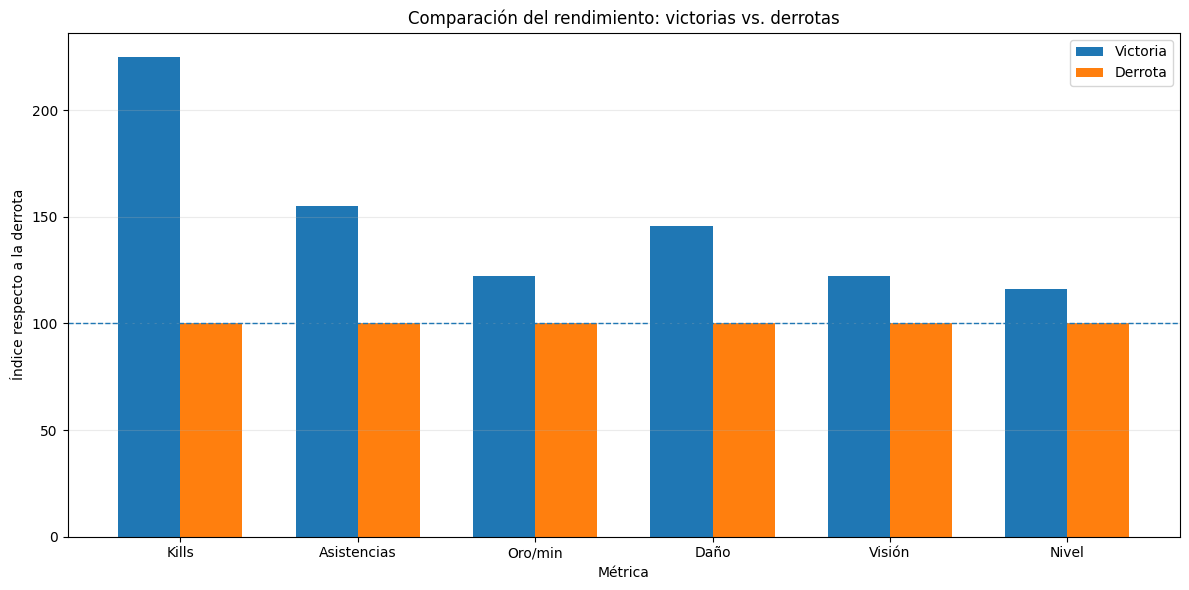

In [ ]:

# 7. GRÁFICO: VICTORIA VS. DERROTA


variables_grafico = [
    "kills",
    "assists",
    "gold_por_min",
    "damage_dealt",
    "vision_score",
    "champ_level"
]

etiquetas_grafico = [
    "Kills",
    "Asistencias",
    "Oro/min",
    "Daño",
    "Visión",
    "Nivel"
]


# 7.1 Calcular promedios


promedios = (
    partidas_validas
    .groupby("resultado")[variables_grafico]
    .mean()
    .reindex(["Victoria", "Derrota"])
)

print("Promedios por resultado:")
display(promedios.round(2))



# 7.2 Crear una comparación porcentual


# Tomamos las derrotas como referencia = 100.
# Ejemplo:
# 120 = 20% más que una derrota
# 100 = igual que una derrota
# 80  = 20% menos que una derrota

comparacion = (
    promedios.loc["Victoria"] /
    promedios.loc["Derrota"] * 100
)


# 7.3 Crear los valores para el gráfico


valor_victoria = comparacion.values
valor_derrota = np.full(len(comparacion), 100)

posiciones = np.arange(len(variables_grafico))
ancho = 0.35


# 7.4 Crear gráfico


fig, eje = plt.subplots(figsize=(12, 6))

eje.bar(
    posiciones - ancho / 2,
    valor_victoria,
    ancho,
    label="Victoria"
)

eje.bar(
    posiciones + ancho / 2,
    valor_derrota,
    ancho,
    label="Derrota"
)

# Línea de referencia
eje.axhline(
    100,
    linewidth=1,
    linestyle="--"
)

# 7.5 Configuración visual

eje.set_xticks(posiciones)
eje.set_xticklabels(etiquetas_grafico)

eje.set_ylabel("Índice respecto a la derrota")
eje.set_xlabel("Métrica")

eje.set_title(
    "Comparación del rendimiento: victorias vs. derrotas"
)

eje.legend()
eje.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

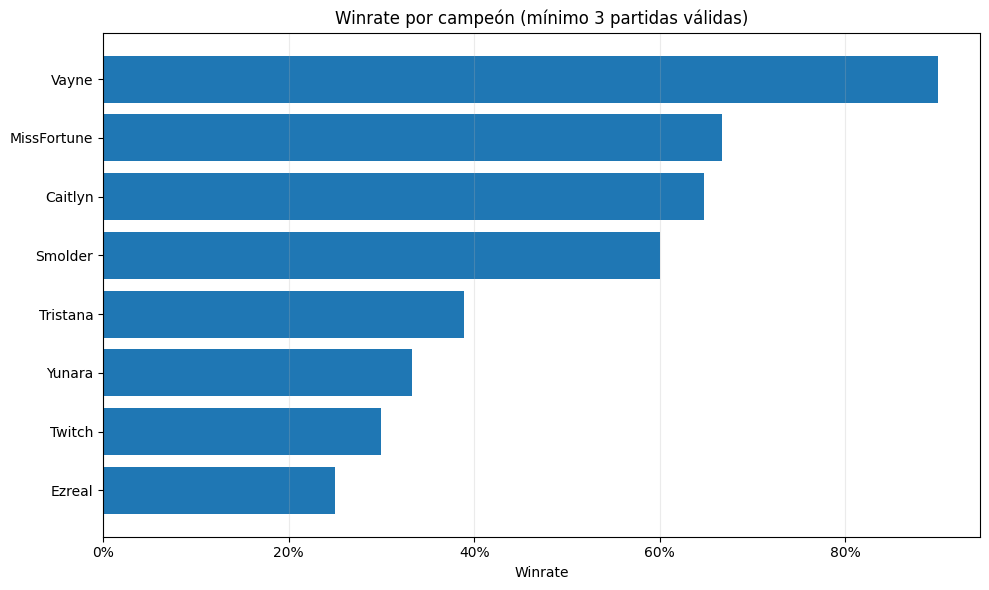

In [ ]:

# 9. GRÁFICO: WINRATE POR CAMPEÓN


grafico_campeones = campeones_representativos.sort_values("winrate")

fig, eje = plt.subplots(figsize=(10, 6))

eje.barh(
    grafico_campeones["champion"],
    grafico_campeones["winrate"] * 100
)

eje.xaxis.set_major_formatter(PercentFormatter(100))
eje.set_xlabel("Winrate")
eje.set_title("Winrate por campeón (mínimo 3 partidas válidas)")
eje.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:

# 10. FORMA RECIENTE


ultimas_20 = partidas_validas.tail(20).copy()
ultimas_10 = partidas_validas.tail(10).copy()

winrate_20 = ultimas_20["win"].mean()
winrate_10 = ultimas_10["win"].mean()

print("FORMA RECIENTE")
print("-" * 40)
print(f"Últimas 20 partidas: {ultimas_20['win'].sum()} victorias de {len(ultimas_20)} ({winrate_20:.1%})")
print(f"Últimas 10 partidas: {ultimas_10['win'].sum()} victorias de {len(ultimas_10)} ({winrate_10:.1%})")


FORMA RECIENTE
----------------------------------------
Últimas 20 partidas: 10 victorias de 20 (50.0%)
Últimas 10 partidas: 4 victorias de 10 (40.0%)


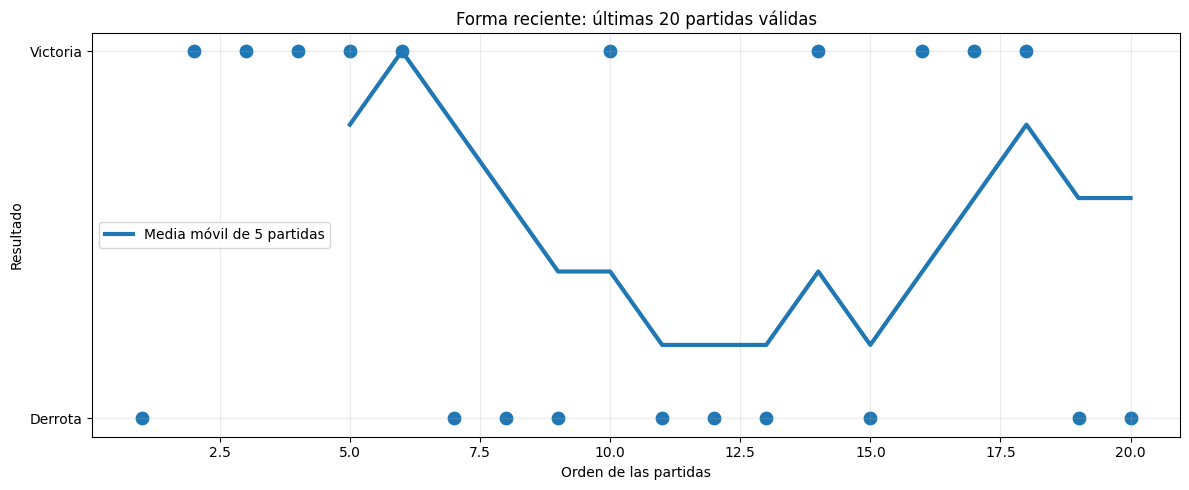

In [ ]:

# 11. GRÁFICO: ÚLTIMAS 20 PARTIDAS


valores_resultado = ultimas_20["win"].astype(int).values
numero_partida = np.arange(1, len(ultimas_20) + 1)

media_movil = (
    pd.Series(valores_resultado)
    .rolling(window=5)
    .mean()
)

fig, eje = plt.subplots(figsize=(12, 5))

eje.scatter(
    numero_partida,
    valores_resultado,
    s=80
)

eje.plot(
    numero_partida,
    media_movil,
    linewidth=3,
    label="Media móvil de 5 partidas"
)

eje.set_yticks([0, 1])
eje.set_yticklabels(["Derrota", "Victoria"])
eje.set_xlabel("Orden de las partidas")
eje.set_ylabel("Resultado")
eje.set_title("Forma reciente: últimas 20 partidas válidas")
eje.grid(alpha=0.25)
eje.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 12. CORRELACIÓN CON EL RESULTADO


variables_correlacion = [
    "kills",
    "deaths",
    "assists",
    "kda",
    "cs_por_min",
    "gold_por_min",
    "gold_earned",
    "damage_dealt",
    "damage_taken",
    "vision_score",
    "wards_placed",
    "wards_killed",
    "champ_level",
    "total_minions"
]

correlaciones = (
    partidas_validas[variables_correlacion]
    .corrwith(partidas_validas["win"].astype(int))
    .sort_values(ascending=False)
)

tabla_correlaciones = correlaciones.to_frame("correlacion_con_victoria")

print("Correlación de Pearson con el resultado de la partida:")
display(tabla_correlaciones.round(3))

Correlación de Pearson con el resultado de la partida:


,correlacion_con_victoria
gold_por_min,0.54
kills,0.53
gold_earned,0.47
champ_level,0.40
kda,0.38
wards_placed,0.34
damage_dealt,0.34
assists,0.33
vision_score,0.23
total_minions,0.22


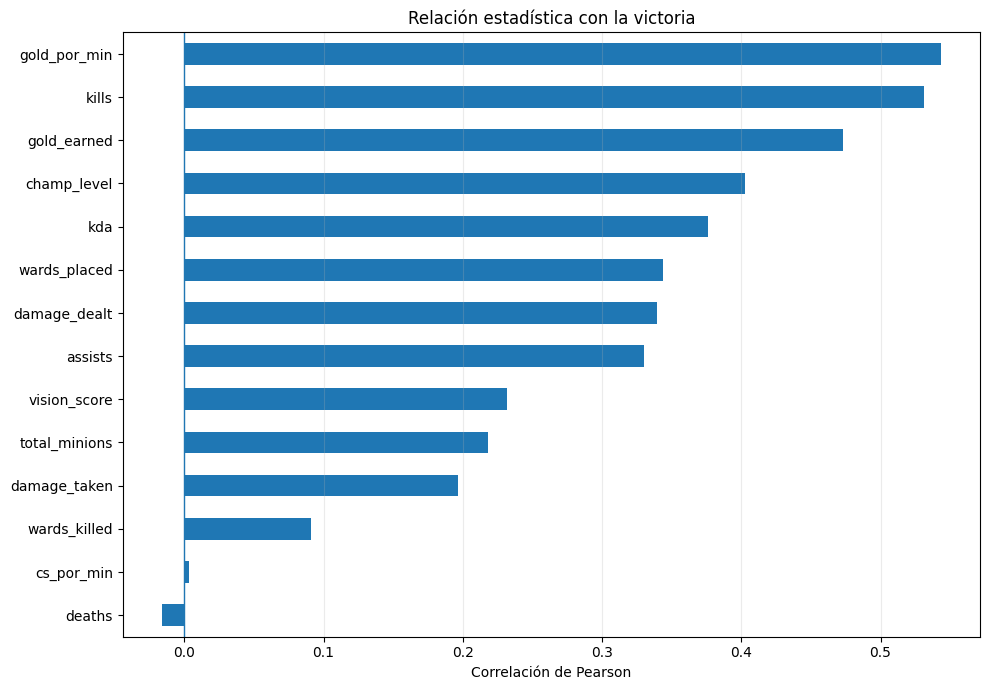

Nota: correlación no significa causalidad.


In [ ]:
# 13. GRÁFICO: CORRELACIONES


fig, eje = plt.subplots(figsize=(10, 7))

correlaciones.sort_values().plot(
    kind="barh",
    ax=eje
)

eje.axvline(0, linewidth=1)
eje.set_title("Relación estadística con la victoria")
eje.set_xlabel("Correlación de Pearson")
eje.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

print("Nota: correlación no significa causalidad.")

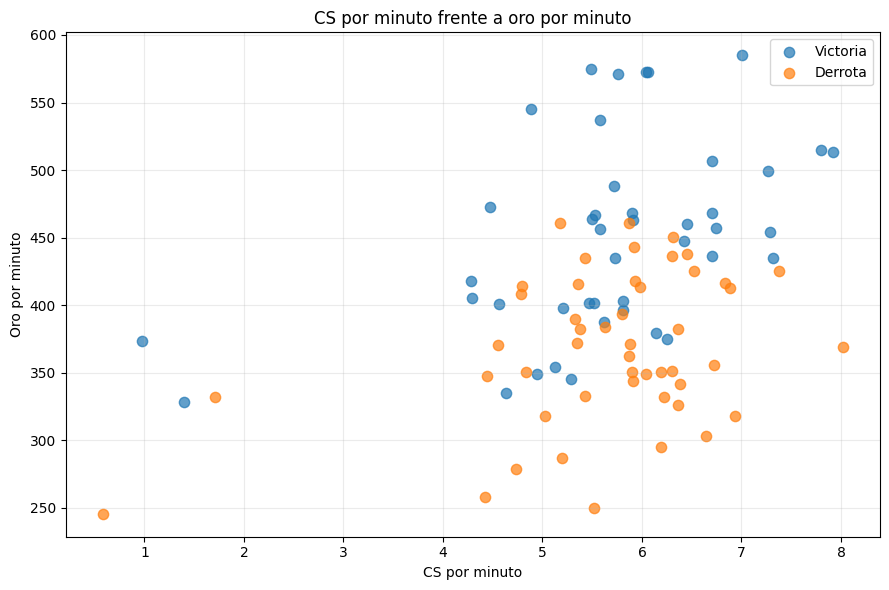

In [ ]:
# 14. CS/MIN FRENTE A ORO/MIN


fig, eje = plt.subplots(figsize=(9, 6))

victorias = partidas_validas[partidas_validas["win"] == True]
derrotas = partidas_validas[partidas_validas["win"] == False]

eje.scatter(
    victorias["cs_por_min"],
    victorias["gold_por_min"],
    s=55,
    alpha=0.7,
    label="Victoria"
)

eje.scatter(
    derrotas["cs_por_min"],
    derrotas["gold_por_min"],
    s=55,
    alpha=0.7,
    label="Derrota"
)

eje.set_xlabel("CS por minuto")
eje.set_ylabel("Oro por minuto")
eje.set_title("CS por minuto frente a oro por minuto")
eje.grid(alpha=0.25)
eje.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 15. DIAGNÓSTICO DEL RENDIMIENTO


promedios_victoria = (
    partidas_validas[partidas_validas["win"] == True]
    [["kills", "assists", "gold_por_min", "damage_dealt", "vision_score", "champ_level"]]
    .mean()
)

promedios_derrota = (
    partidas_validas[partidas_validas["win"] == False]
    [["kills", "assists", "gold_por_min", "damage_dealt", "vision_score", "champ_level"]]
    .mean()
)

diferencias = (promedios_victoria - promedios_derrota).to_frame("diferencia_victoria_menos_derrota")

display(diferencias.round(2))

,diferencia_victoria_menos_derrota
kills,5.21
assists,3.10
gold_por_min,81.11
damage_dealt,8718.84
vision_score,4.49
champ_level,2.16


In [ ]:
# 16. RECOMENDACIONES PARA EL JUGADOR


print("RECOMENDACIONES DE MEJORA")
print("=" * 55)

print(
    "1. Convertir las ventajas: después de conseguir una ventaja, "
    "buscar placas, torre, objetivo, reset o rotación útil."
)

print(
    "2. Priorizar generación de recursos e impacto, no solamente "
    "farmear por farmear."
)

print(
    "3. Mantener visión antes de entrar al río o disputar objetivos."
)

print(
    "4. Trabajar con un grupo estable de 2 o 3 campeones para "
    "reducir la variabilidad y facilitar el aprendizaje."
)

print(
    "5. Después de cada partida registrar una decisión positiva "
    "y una decisión que debería repetirse de otra manera."
)

RECOMENDACIONES DE MEJORA
1. Convertir las ventajas: después de conseguir una ventaja, buscar placas, torre, objetivo, reset o rotación útil.
2. Priorizar generación de recursos e impacto, no solamente farmear por farmear.
3. Mantener visión antes de entrar al río o disputar objetivos.
4. Trabajar con un grupo estable de 2 o 3 campeones para reducir la variabilidad y facilitar el aprendizaje.
5. Después de cada partida registrar una decisión positiva y una decisión que debería repetirse de otra manera.
